# Étape 4 (J4) : Clustering des pays et restitution opérationnelle

Dans cette dernière étape, nous allons :
1. Réaliser une classification non supervisée (**K-Means**) pour regrouper les pays selon leur profil alimentaire et nutritionnel.
2. Déterminer le nombre optimal de clusters ($k$) à l'aide de la méthode du coude (Elbow Method) et du score de silhouette.
3. Interpréter chaque cluster à l'aide de variables descriptives clés et leur attribuer un nom métier.
4. Formuler des recommandations opérationnelles pour la FAO.

## 1.Importation des bibliothèques et préparation des données

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
%matplotlib inline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns

In [2]:
df_global = pd.read_csv('data/dataset_global_fao.csv')
print(df_global.shape)
df_global.head()

(171, 12)


,Zone,Code zone,Kcal_vegetaux,Kcal_animaux,Population_milliers,SousAlimentation_millions,Disponibilite_calorique_totale_kcal,Population_totale,Taux_sousnutrition_pct,Part_animaux_pct,Continent,ISO3
0,Afghanistan,2,1871.0,216.0,30552,7.9,2087.0,30552000,25.857554,10.349784,Asia,AFG
1,Afrique du Sud,202,2533.0,487.0,52776,2.6,3020.0,52776000,4.926482,16.125828,Africa,ZAF
2,Albanie,3,2203.0,985.0,3173,0.2,3188.0,3173000,6.303183,30.897114,Europe,ALB
3,Algérie,4,2915.0,378.0,39208,1.7,3293.0,39208000,4.335850,11.478895,Africa,DZA
4,Allemagne,79,2461.0,1042.0,82727,NaN,3503.0,82727000,NaN,29.745932,Europe,DEU


In [3]:
df = pd.read_csv('data/dataset_global_fao_impute.csv')  
print(df.shape)
df.head(5)

(171, 13)


,Zone,Code zone,Kcal_vegetaux,Kcal_animaux,Population_milliers,SousAlimentation_millions,Disponibilite_calorique_totale_kcal,Population_totale,Taux_sousnutrition_pct,Part_animaux_pct,Continent,ISO3,Part_vegetaux_pct
0,Afghanistan,2,1871.0,216.0,30552,7.9,2087.0,30552000,25.857554,10.349784,Asia,AFG,89.650216
1,Afrique du Sud,202,2533.0,487.0,52776,2.6,3020.0,52776000,4.926482,16.125828,Africa,ZAF,83.874172
2,Albanie,3,2203.0,985.0,3173,0.2,3188.0,3173000,6.303183,30.897114,Europe,ALB,69.102886
3,Algérie,4,2915.0,378.0,39208,1.7,3293.0,39208000,4.335850,11.478895,Africa,DZA,88.521105
4,Angola,7,2221.0,253.0,21472,8.1,2474.0,21472000,37.723547,10.226354,Africa,AGO,89.773646


In [43]:
print(df.columns.tolist())

['Zone', 'Code zone', 'Kcal_vegetaux', 'Kcal_animaux', 'Population_milliers', 'SousAlimentation_millions', 'Disponibilite_calorique_totale_kcal', 'Population_totale', 'Taux_sousnutrition_pct', 'Part_animaux_pct', 'Continent', 'ISO3', 'Part_vegetaux_pct', 'Cluster']


In [13]:
df_clustering = df[~df['Zone'].isin(['Chine', 'Inde'])].copy()
X_coude = df_clustering[[
    'Disponibilite_calorique_totale_kcal',
    'Part_vegetaux_pct',
    'Part_animaux_pct',
    'Taux_sousnutrition_pct',
    'Population_totale',
]]

scaler = StandardScaler()
X_coude_scaled = scaler.fit_transform(X_coude)

print(f"Nombre de pays retenus pour le clustering : {X_coude_scaled.shape[0]}")

Nombre de pays retenus pour le clustering : 169


## 2.Détermination de $k$ (Méthode du coude et Score de Silhouette)

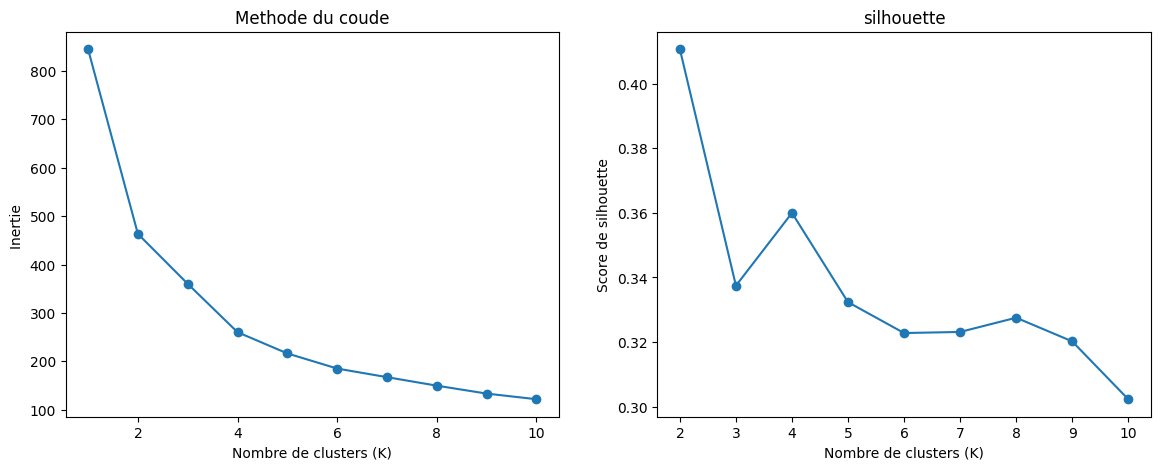

In [44]:
# Test de plusieurs valeurs de k (de 1 à 10)
inerties = []
silhouettes = []
K_range = range(1, 11)

for k in K_range:
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = km.fit_predict(X_coude_scaled)
  inerties.append(km.inertia_)
  # silhouette_score n'est pas défini pour k=1 (il faut au moins 2 clusters)
  if k >= 2:
    silhouettes.append(silhouette_score(X_coude_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range,inerties, marker="o")
axes[0].set_xlabel("Nombre de clusters (K)")
axes[0].set_ylabel("Inertie ")
axes[0].set_title("Methode du coude")

axes[1].plot(list(K_range)[1:],silhouettes, marker="o")
axes[1].set_xlabel("Nombre de clusters (K)")
axes[1].set_ylabel("Score de silhouette")
axes[1].set_title("silhouette")

plt.show()

## 3.Entraînement du modèle K-Means final

In [21]:
n_c = 4
kmeans_final = KMeans(n_clusters=n_c, random_state=42, n_init=10)
df_clustering['Cluster'] = kmeans_final.fit_predict(X_coude_scaled)

print(f"total clusters: {df_clustering['Cluster'].nunique()}")
print(df_clustering['Cluster'].value_counts().sort_index())

total clusters: 4
Cluster
0    63
1    52
2    45
3     9
Name: count, dtype: int64


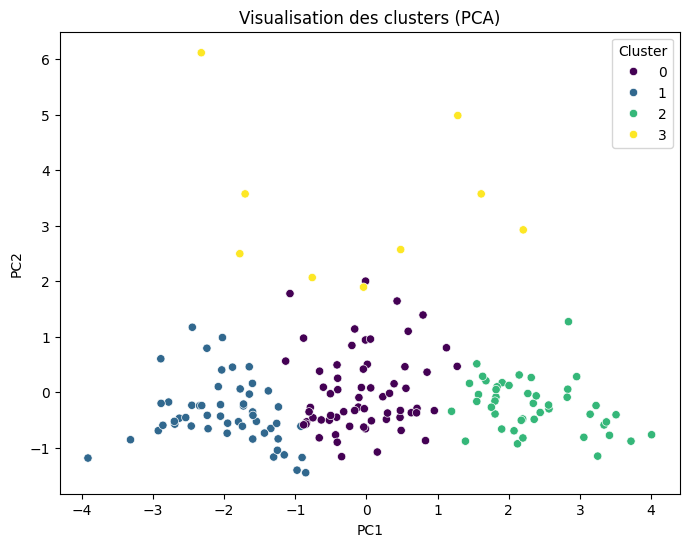

In [46]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_coude_scaled)
df_clustering['PC1'] = X_pca[:, 0]
df_clustering['PC2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clustering, x='PC1', y='PC2', hue='Cluster', palette='viridis')
plt.title("Visualisation des clusters (PCA)")
plt.show()

In [47]:
for c in sorted(df_clustering['Cluster'].unique()):
    print(f"--- Cluster {c} ---")
    print(df_clustering[df_clustering['Cluster'] == c]['Zone'].sample(2, random_state=42).to_string(index=False))
  

--- Cluster 0 ---
                        Ukraine
Saint-Vincent-et-les Grenadines
--- Cluster 1 ---
            Estonie
Polynésie française
--- Cluster 2 ---
Zambie
 Niger
--- Cluster 3 ---
    Japon
Indonésie


In [48]:
df_clustering[['Zone','Cluster']].head()

,Zone,Cluster
0,Afghanistan,2
1,Afrique du Sud,0
2,Albanie,1
3,Algérie,0
4,Angola,2


## 4.Interprétation des clusters

In [49]:
cluster_profil = df_clustering.groupby('Cluster')[[
    'Disponibilite_calorique_totale_kcal',
    'Taux_sousnutrition_pct',
    'Part_animaux_pct',
    'Part_vegetaux_pct',
    'Population_milliers',
]].mean().round(1)

cluster_profil['Nb_pays'] = df_clustering['Cluster'].value_counts()
cluster_profil.sort_values('Cluster')

,Disponibilite_calorique_totale_kcal,Taux_sousnutrition_pct,Part_animaux_pct,Part_vegetaux_pct,Population_milliers,Nb_pays
Cluster,,,,,,
0,2888.8,8.3,17.3,82.7,19677.1,63
1,3211.1,2.3,29.2,70.8,13425.2,52
2,2338.7,26.1,7.8,92.2,15906.8,45
3,2942.9,7.8,17.1,82.9,186104.7,9


In [50]:
df_clustering[df_clustering['Cluster'] == 3][['Zone', 'Population_totale', 'Disponibilite_calorique_totale_kcal', 'Taux_sousnutrition_pct']].sort_values('Population_totale', ascending=False)

,Zone,Population_totale,Disponibilite_calorique_totale_kcal,Taux_sousnutrition_pct
169,États-Unis d'Amérique,320051000,3682.0,0.000000
35,Indonésie,249866000,2776.0,9.044848
107,Brésil,200362000,3262.0,0.000000
63,Pakistan,182143000,2438.0,20.917631
58,Nigéria,173615000,2700.0,7.718227
8,Bangladesh,156595000,2453.0,16.667199
121,Fédération de Russie,142834000,3360.0,0.000000
130,Japon,127144000,2747.0,11.483918
51,Mexique,122332000,3068.0,4.332472


### Interprétation et Profils des Clusters Identifiés :

* **Cluster 0 : « Pays à situation équilibrée »**
  * *Caractéristiques* : Disponibilité calorique correcte (2888 kcal/j), taux de sous-nutrition faible (8.3 %), alimentation (82.7 % végétaux, 17.3 % d'origine animale). 63 pays.


* **Cluster 1 : « Pays en sécurité alimentaire élevée »**
  * *Caractéristiques* : Disponibilité calorique la plus élevée (3211.1 kcal/j), part animale la plus forte (29,2 %), taux de sous-nutrition quasi nul (2,3 %). 52 pays.

* **Cluster 2 : « Pays en insécurité alimentaire »**
  * *Caractéristiques* : Disponibilité calorique la plus faible (2338.7 kcal/j), taux de sous-nutrition le plus élevé (26,1 %), régime ultra-dominé par les végétaux (92,2 %, seulement 7,8 % d'origine animale). 45 pays.

* **Cluster 3 : « Pays très peuplés, mais très différents en sécurité alimentaire »**
  * Un petit groupe de 9 pays très peuplés (États-Unis, Indonésie, Brésil, Pakistan, Nigéria, Bangladesh, Russie, Japon, Mexique — environ 186 millions d'habitants en moyenne), qui n'ont pas grand-chose en commun sur le plan alimentaire : le taux de sous-nutrition va de 0 % (États-Unis, Brésil, Russie) à 20,9 % (Pakistan).
  * Cela montre une limite du choix d'inclure `Population_totale` parmi les variables du clustering : quand un pays a une population très supérieure aux autres, cet écart pèse plus lourd que les autres variables dans le calcul des distances entre pays. Résultat : ces 9 pays se retrouvent regroupés ensemble à cause de leur taille, alors que sans cette variable, ils auraient sans doute été répartis dans les Clusters 0, 1 et 2 selon leur véritable situation alimentaire.


### Restitution et Recommandations Opérationnelles pour la FAO

À l'issue de cette analyse globale et du clustering des profils alimentaires mondiaux (K=4), trois recommandations sont formulées à destination de la FAO :

**1. Concentrer l'aide d'urgence sur les pays du Cluster 2**
Les pays du Cluster 2 (« Insécurité alimentaire ») cumulent les deux signaux les plus graves : la plus faible disponibilité calorique de tout l'échantillon (2338,7 kcal/j) et le taux de sous-nutrition le plus élevé (26,1 %), avec une alimentation presque entièrement végétale (7,8 % seulement de protéines animales). C'est ce groupe qui doit être prioritaire pour les programmes d'aide alimentaire de la FAO.

**2. Prévenir les risques de surconsommation dans le Cluster 1**
À l'inverse, les pays du Cluster 1 (« Sécurité alimentaire élevée ») ont la disponibilité calorique la plus haute (3211,1 kcal/j), la plus forte part de protéines animales (29,2 %), et un taux de sous-nutrition quasi nul (2,3 %). Pour eux, le problème n'est plus le manque de nourriture mais l'excès : la FAO pourrait orienter ses recommandations vers l'éducation nutritionnelle et la prévention du surpoids.

**3. Ne pas traiter le Cluster 3 comme un groupe homogène**
Le Cluster 3 réunit 9 pays très peuplés (États-Unis, Indonésie, Brésil, Pakistan, Nigéria, Bangladesh, Russie, Japon, Mexique), mais ce regroupement vient uniquement de leur taille de population, pas d'un profil alimentaire commun — le taux de sous-nutrition y va de 0 % à 20,9 % selon les pays. Plutôt qu'une recommandation unique pour ce groupe, la FAO devrait traiter chacun de ces pays selon la situation qui lui correspond réellement (proche du Cluster 0, 1 ou 2), et suivre ces géants démographiques séparément dans les futures analyses, car leur poids statistique peut fausser des regroupements basés sur la population.